# Example: Single Contract Payoff and Profit
In the lecture, we wrote the payoff, profit, and breakeven of call and put contracts. What do they look like for real contracts, and how much can each position gain or lose?

> __Learning Objectives:__
> 
> By the end of this example, you should be able to:
> * __Construct option contract models:__ A contract model holds the strike price, the premium, and the position direction, long or short. We'll read the premiums from a real options chain and build a call and a put in each direction.
> * __Compute payoff and profit diagrams:__ We'll evaluate each position for share prices at expiration from zero to twice the strike. We'll convert the per-share results to dollars at 100 shares per contract.
> * __Verify the analytical results:__ The lecture gives each contract's breakeven and the limits on its profit and loss. We'll compute the breakeven, maximum profit, and maximum loss of each position and check them against the diagrams.

Let's get started!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

  Activating 

project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/).

### Data
To start, load an end-of-day options chain from the course's options archive, which holds the chains of 31 tickers captured after each close from April 13 to October 8, 2026. [The `MyOptionsEODChainDataSet(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyOptionsEODChainDataSet) returns the chain for one ticker, trading session, and expiration, with the share price on that session. Store the data in the `metadata::Dict{String,Any}` and `optionschain::DataFrame` variables.

In [2]:
ticker = "NVDA"; # underlying ticker: any of the 31 tickers in the archive
quote_date = Date(2026, 10, 8); # trading session of the quotes (the archive's last session)
target_dte = 45; # days to expiration target, one of the archive's ladder values (2, 7, 14, 30, 45)

metadata, optionschain = let

    # initialize: the first call downloads the archive (about 112 MB) -
    session = MyOptionsEODChainDataSet(ticker = ticker, date = quote_date); # every expiration that session

    # keep the expiration matched to the target -
    expiration = filter(:target_dte => ==(target_dte), session.data).expiration |> first;
    options_dataset = MyOptionsEODChainDataSet(ticker = ticker, date = quote_date, expiration = expiration);
    metadata = options_dataset.metadata;
    optionschain = options_dataset.data;

    (metadata, optionschain) # return
end;

What's in the metadata dictionary?

In [3]:
metadata |> keys

KeySet for a Dict{String, Any} with 11 entries. Keys:
  "underlying_high"
  "underlying_low"
  "ticker"
  "underlying_close"
  "capture_ts"
  "quote_date"
  "DTE"
  "underlying_open"
  "source"
  "expirations"
  "expiration_date"

What about the optionschain variable?

In [4]:
select(optionschain, :expiration, :type, :strike, :bid, :ask, :mid) # the columns we use; the chain has 19

Row,expiration,type,strike,bid,ask,mid
,Date,String,Float64,Float64,Float64,Float64
1,2026-11-20,call,2.5,223.85,234.5,229.175
2,2026-11-20,call,5.0,221.32,225.24,223.28
3,2026-11-20,call,7.5,220.34,227.43,223.885
4,2026-11-20,call,10.0,219.59,226.54,223.065
5,2026-11-20,call,12.5,211.46,223.19,217.325
6,2026-11-20,call,15.0,211.59,219.98,215.785
7,2026-11-20,call,17.5,212.29,215.81,214.05
8,2026-11-20,call,20.0,206.22,216.42,211.32
9,2026-11-20,call,22.5,207.09,215.73,211.41


### Constants
Finally, let's set the constants we'll use later in this notebook. The comments describe the constants, their units, and permissible values:

In [5]:
Sₒ = metadata["underlying_close"]; # share price at the close of the quote date (USD/share)
q = 100; # 100 shares per contract (shares/contract)
DTE = metadata["DTE"]; # days to expiration (days)
K = optionschain.strike[argmin(abs.(optionschain.strike .- Sₒ))]; # at-the-money strike, nearest Sₒ (USD/share)

___

## Task 1: Call Contracts, Long and Short
In this task, we analyze the payoff and profit of a call contract held __long__ ($\theta=+1$) and sold __short__ ($\theta=-1$).

Let's extract the call option data from the `optionschain::DataFrame` dataset at the strike $K$, and build two instances of [the `MyAmericanCallContractModel` type](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/derivatives/#VLQuantitativeFinancePackage.MyAmericanCallContractModel) with [the `build(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/derivatives/#VLQuantitativeFinancePackage.build-Tuple{Type{MyAmericanCallContractModel},%20NamedTuple}), one for each direction.

> __Why an American contract model?__ Listed options on stocks and ETFs are American-style, so the premiums in this chain are American premiums. A contract held to expiration pays the same in either style, so a European model would give the same diagrams. The style matters for the premium: the lecture showed that an American contract is worth at least as much as a European one.

In [6]:
C₀, call_long, call_short = let

    # initialize: the premium is the mid of the closing bid and ask (USD/share) -
    C₀ = filter([:strike, :type] => (k, t) -> (k == K && t == "call"), optionschain)[1, :mid];

    # build one model per direction: θ = +1 long, θ = -1 short -
    call_long  = build(MyAmericanCallContractModel, (K = K, premium = C₀, sense =  1, copy = 1));
    call_short = build(MyAmericanCallContractModel, (K = K, premium = C₀, sense = -1, copy = 1));

    (C₀, call_long, call_short); # return
end;

The buyer pays this premium, $\mathcal{P}_{c}$ (`C₀` in the code), and the seller collects it. Premiums are quoted __per share__, so at 100 shares per contract the cash that changes hands is 100 times the premium:

In [7]:
let
    # the call premium and the cash for one contract, q = 100 shares -
    df = DataFrame(
        quantity = ["share price Sₒ", "strike K", "call premium C₀", "cash for one contract",
            "days to expiration"],
        value    = Any[round(Sₒ, digits = 2), K, round(C₀, digits = 2), round(q*C₀, digits = 2), DTE],
        units    = ["USD/share", "USD/share", "USD/share", "USD", "days"]
    );
    pretty_table(df; column_labels = ["quantity", "value", "units"], alignment = [:l, :r, :l],
        table_format = TextTableFormat(borders = text_table_borders__compact));
end

 ----------------------- -------- -----------
  quantity                 value   units     
 ----------------------- -------- -----------
  share price Sₒ          230.57   USD/share
  strike K                 230.0   USD/share
  call premium C₀          12.15   USD/share
  cash for one contract   1215.0   USD
  days to expiration          43   days
 ----------------------- -------- -----------


### Visualize Payoff and Profit
Next, we use [the `payoff(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/derivatives/#VLQuantitativeFinancePackage.payoff) and [the `profit(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/derivatives/#VLQuantitativeFinancePackage.profit) to evaluate both positions for share prices at expiration from $S(T)=0$ to twice the strike. We start at zero because a share price cannot be negative. In Task 2, that limit sets the put's largest payoff.

In [8]:
S_expiration, payoff_call, profit_call_long, profit_call_short = let

    # sweep from the left boundary S(T) = 0 to S(T) = 2K -
    S_expiration = range(0.0, stop = 2.0*K, step = 0.5) |> collect; # USD/share

    payoff_call       = payoff([call_long],  S_expiration);  # per share
    profit_call_long  = profit([call_long],  S_expiration);  # per share
    profit_call_short = profit([call_short], S_expiration);  # per share

    (S_expiration, payoff_call, profit_call_long, profit_call_short); # return
end;

Let's plot the long payoff against the long and short profit using [the `plot(...)` function from the `Plots.jl` package](https://github.com/JuliaPlots/Plots.jl). The two profit curves are exact reflections of one another about zero: what the buyer gains, the seller loses.

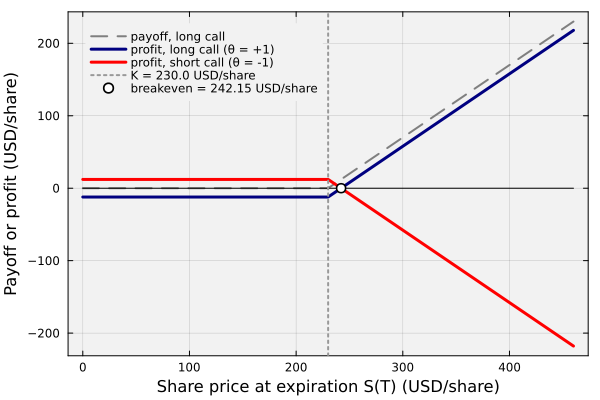

In [9]:
let
    breakeven = K + C₀;

    plot(S_expiration, payoff_call[:,2], lw = 2, c = :gray50, ls = :dash, label = "payoff, long call",
        bg = "gray95", background_color_outside = "white", framestyle = :box, fg_legend = :transparent);
    plot!(S_expiration, profit_call_long[:,2],  lw = 3, c = :navyblue, label = "profit, long call (θ = +1)");
    plot!(S_expiration, profit_call_short[:,2], lw = 3, c = :red,      label = "profit, short call (θ = -1)");
    plot!(S_expiration, zeros(length(S_expiration)), lw = 1, c = :black, label = "");

    vline!([K], lw = 2, c = :gray60, ls = :dot, label = "K = $(K) USD/share");
    scatter!([breakeven], [0.0], mc = :white, msc = :black, msw = 2, ms = 5,
        label = "breakeven = $(round(breakeven, digits=2)) USD/share");

    xlabel!("Share price at expiration S(T) (USD/share)", fontsize = 18);
    ylabel!("Payoff or profit (USD/share)", fontsize = 18);
end

### Breakeven Analysis for a Call Contract
The breakeven is the share price at expiration where the profit is zero. Setting the long call profit to zero gives the lecture's breakeven:
$$
\begin{align*}
P_{c}^{\text{buyer}}(K,S(T)) &= V_{c}(K,S(T)) - \mathcal{P}_{c}\\
0 &= \max\left(S(T)-K,\,0\right) - \mathcal{P}_{c}\\
\mathcal{P}_{c} &= S(T)-K \quad\text{(the exercised branch, since } \mathcal{P}_{c}>0 \text{ requires } S(T)>K)\\
S(T) &= K + \mathcal{P}_{c}
\end{align*}
$$
The short call profit is $P_{c}^{\text{seller}} = -P_{c}^{\text{buyer}}$, so it is zero at the same price.

The same expression gives the bounds. For $S(T)\leq K$, the call expires worthless, so the buyer loses the premium and the seller keeps it. Above the strike, the long profit grows without limit and the short loss grows with it. Let's check these results numerically:

In [10]:
let
    breakeven = K + C₀;
    i_be = argmin(abs.(S_expiration .- breakeven)); # grid point nearest the breakeven

    # compare the swept results with the lecture's formulas (USD/share) -
    r(x) = round(x, digits = 2);
    df = DataFrame(
        quantity = ["breakeven", "long call maximum loss", "long call profit at S(T) = 2K",
            "short call maximum profit", "short call profit at S(T) = 2K"],
        value    = r.([breakeven, minimum(profit_call_long[:,2]), profit_call_long[end,2],
            maximum(profit_call_short[:,2]), profit_call_short[end,2]]),
        formula  = ["K + C₀", "-C₀", "no upper bound", "C₀", "no lower bound"]
    );
    pretty_table(df; column_labels = ["quantity", "value (USD/share)", "lecture formula"],
        alignment = [:l, :r, :l], table_format = TextTableFormat(borders = text_table_borders__compact));

    # checks: breakeven, mirror image, and the premium bounds -
    @assert abs(profit_call_long[i_be,2]) ≤ 0.5 "long call profit is not zero at K + C₀"
    @assert profit_call_long[:,2] ≈ -profit_call_short[:,2] "long and short profits are not mirror images"
    @assert minimum(profit_call_long[:,2]) ≈ -C₀ "long call maximum loss is not C₀"
    @assert maximum(profit_call_short[:,2]) ≈ C₀ "short call maximum profit is not C₀"
    println("All call-contract checks passed.");
end

 -------------------------------- ------------------- -----------------
  quantity                         value (USD/share)   lecture formula 
 -------------------------------- ------------------- -----------------
  breakeven                                   242.15   K + C₀
  long call maximum loss                      -12.15   -C₀
  long call profit at S(T) = 2K               217.85   no upper bound
  short call maximum profit                    12.15   C₀
  short call profit at S(T) = 2K             -217.85   no lower bound
 -------------------------------- ------------------- -----------------
All call-contract checks passed.

___

## Task 2: Put Contracts, Long and Short
In this task, we repeat the analysis for a put contract held __long__ ($\theta=+1$) and sold __short__ ($\theta=-1$), using [the `MyAmericanPutContractModel` type](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/derivatives/#VLQuantitativeFinancePackage.MyAmericanPutContractModel).

In [11]:
P₀, put_long, put_short = let

    # initialize: the premium is the mid of the closing bid and ask (USD/share) -
    P₀ = filter([:strike, :type] => (k, t) -> (k == K && t == "put"), optionschain)[1, :mid];

    # build one model per direction: θ = +1 long, θ = -1 short -
    put_long  = build(MyAmericanPutContractModel, (K = K, premium = P₀, sense =  1, copy = 1));
    put_short = build(MyAmericanPutContractModel, (K = K, premium = P₀, sense = -1, copy = 1));

    (P₀, put_long, put_short); # return
end;

Again, the quoted premium, $\mathcal{P}_{p}$ (`P₀` in the code), is per share, and the cash for one contract is 100 times larger:

In [12]:
let
    # the put premium and the cash for one contract, q = 100 shares -
    df = DataFrame(
        quantity = ["strike K", "put premium P₀", "cash for one contract"],
        value    = [K, round(P₀, digits = 2), round(q*P₀, digits = 2)],
        units    = ["USD/share", "USD/share", "USD"]
    );
    pretty_table(df; column_labels = ["quantity", "value", "units"], alignment = [:l, :r, :l],
        table_format = TextTableFormat(borders = text_table_borders__compact));
end

 ----------------------- -------- -----------
  quantity                 value   units     
 ----------------------- -------- -----------
  strike K                 230.0   USD/share
  put premium P₀           10.64   USD/share
  cash for one contract   1063.5   USD
 ----------------------- -------- -----------


### Visualize Payoff and Profit
We sweep the same window, from $S(T)=0$ to twice the strike.

In [13]:
payoff_put, profit_put_long, profit_put_short = let

    # the call's window, from S(T) = 0 to S(T) = 2K -
    payoff_put       = payoff([put_long],  S_expiration);  # per share
    profit_put_long  = profit([put_long],  S_expiration);  # per share
    profit_put_short = profit([put_short], S_expiration);  # per share

    (payoff_put, profit_put_long, profit_put_short); # return
end;

Let's plot the long payoff against the long and short profit, with the bounds at $S(T)=0$ marked:

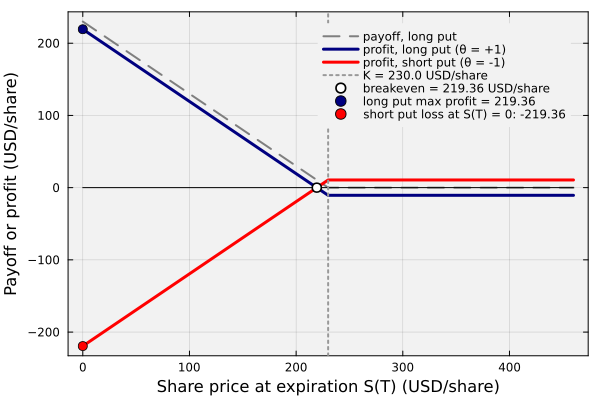

In [14]:
let
    breakeven = K - P₀;

    plot(S_expiration, payoff_put[:,2], lw = 2, c = :gray50, ls = :dash, label = "payoff, long put",
        bg = "gray95", background_color_outside = "white", framestyle = :box, fg_legend = :transparent);
    plot!(S_expiration, profit_put_long[:,2],  lw = 3, c = :navyblue, label = "profit, long put (θ = +1)");
    plot!(S_expiration, profit_put_short[:,2], lw = 3, c = :red,      label = "profit, short put (θ = -1)");
    plot!(S_expiration, zeros(length(S_expiration)), lw = 1, c = :black, label = "");

    vline!([K], lw = 2, c = :gray60, ls = :dot, label = "K = $(K) USD/share");
    scatter!([breakeven], [0.0], mc = :white, msc = :black, msw = 2, ms = 5,
        label = "breakeven = $(round(breakeven, digits=2)) USD/share");
    scatter!([0.0], [K - P₀], c = :navyblue, ms = 5,
        label = "long put max profit = $(round(K - P₀, digits=2))");
    scatter!([0.0], [P₀ - K], c = :red, ms = 5,
        label = "short put loss at S(T) = 0: $(round(P₀ - K, digits=2))");

    xlabel!("Share price at expiration S(T) (USD/share)", fontsize = 18);
    ylabel!("Payoff or profit (USD/share)", fontsize = 18);
end

### Breakeven and Bounds for a Put Contract
Setting the long put profit to zero gives the lecture's put breakeven:
$$
\begin{align*}
P_{p}^{\text{buyer}}(K,S(T)) &= V_{p}(K,S(T)) - \mathcal{P}_{p}\\
0 &= \max\left(K-S(T),\,0\right) - \mathcal{P}_{p}\\
\mathcal{P}_{p} &= K-S(T) \quad\text{(the exercised branch, since } \mathcal{P}_{p}>0 \text{ requires } S(T)<K)\\
S(T) &= K - \mathcal{P}_{p}
\end{align*}
$$
The bounds differ from the call because the share price cannot fall below zero:
$$
0 \leq S(T) \quad\Longrightarrow\quad V_{p}(K,S(T)) = \max\left(K-S(T),\,0\right) \leq K
$$
The put payoff can never exceed the strike. So the long put's maximum profit and the short put's maximum loss are both $K-\mathcal{P}_{p}$, reached at $S(T)=0$. An uncovered short call has no such limit, because $S(T)$ has no upper bound.

Let's verify:

In [15]:
let
    breakeven = K - P₀;
    i_be = argmin(abs.(S_expiration .- breakeven)); # grid point nearest the breakeven

    # compare the swept results with the lecture's formulas (USD/share) -
    r(x) = round(x, digits = 2);
    df = DataFrame(
        quantity = ["breakeven", "long put maximum loss", "long put maximum profit",
            "short put maximum profit", "short put maximum loss"],
        value    = r.([breakeven, minimum(profit_put_long[:,2]), maximum(profit_put_long[:,2]),
            maximum(profit_put_short[:,2]), minimum(profit_put_short[:,2])]),
        formula  = ["K - P₀", "-P₀", "K - P₀", "P₀", "P₀ - K"]
    );
    pretty_table(df; column_labels = ["quantity", "value (USD/share)", "lecture formula"],
        alignment = [:l, :r, :l], table_format = TextTableFormat(borders = text_table_borders__compact));

    # checks: breakeven, mirror image, and the finite bounds -
    @assert abs(profit_put_long[i_be,2]) ≤ 0.5 "long put profit is not zero at K - P₀"
    @assert profit_put_long[:,2] ≈ -profit_put_short[:,2] "long and short profits are not mirror images"
    @assert minimum(profit_put_long[:,2]) ≈ -P₀ "long put maximum loss is not P₀"
    @assert maximum(profit_put_long[:,2]) ≈ K - P₀ "long put maximum profit is not K - P₀"
    println("All put-contract checks passed.");
end

 -------------------------- ------------------- -----------------
  quantity                   value (USD/share)   lecture formula 
 -------------------------- ------------------- -----------------
  breakeven                             219.36   K - P₀
  long put maximum loss                 -10.64   -P₀
  long put maximum profit               219.36   K - P₀
  short put maximum profit               10.64   P₀
  short put maximum loss               -219.36   P₀ - K
 -------------------------- ------------------- -----------------
All put-contract checks passed.


___

## Task 3: The Four Positions Side by Side
In this task, we collect the four positions in one table for a single contract, at 100 shares per contract: the premium, maximum profit, and maximum loss in dollars, and the breakeven share price.

In [16]:
four_positions = let

    # collect the results for one contract, q = 100 shares: USD, except the breakeven (USD/share) -
    r(x) = round(x, digits = 2);
    df = DataFrame(
        position   = ["long call", "short call", "long put", "short put"],
        premium    = r.(q .* [C₀, C₀, P₀, P₀]),
        max_profit = ["unbounded", "$(r(q*C₀))", "$(r(q*(K - P₀)))", "$(r(q*P₀))"],
        max_loss   = ["$(r(q*C₀))", "unbounded", "$(r(q*P₀))", "$(r(q*(K - P₀)))"],
        breakeven  = r.([K + C₀, K + C₀, K - P₀, K - P₀])
    );

    # show every row and column, with the units in the labels -
    pretty_table(df;
        column_labels = ["position", "premium (USD)", "max profit (USD)", "max loss (USD)",
            "breakeven (USD/share)"],
        alignment = [:l, :r, :r, :r, :r],
        table_format = TextTableFormat(borders = text_table_borders__compact),
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false);

    df # return
end;

 ------------ --------------- ------------------ ---------------- -----------------------
  position     premium (USD)   max profit (USD)   max loss (USD)   breakeven (USD/share) 
 ------------ --------------- ------------------ ---------------- -----------------------
  long call           1215.0          unbounded           1215.0                  242.15
  short call          1215.0             1215.0        unbounded                  242.15
  long put            1063.5            21936.5           1063.5                  219.36
  short put           1063.5             1063.5          21936.5                  219.36
 ------------ --------------- ------------------ ---------------- -----------------------


Only the short call has an unbounded maximum loss.

___

## Summary
In this example, we built the four single-contract positions from a real options chain and computed their payoff and profit at expiration. We then checked each breakeven, maximum profit, and maximum loss against the diagrams.

> __Key Takeaways:__
>
> * __Payoff versus profit:__ The payoff depends only on the strike and the share price at expiration. We computed the profit by adjusting the payoff for the premium, which the buyer pays and the seller collects.
> * __The buyer and the seller share a breakeven:__ The long and short profits are mirror images about zero, so both sides break even at the same share price. We checked that a call breaks even at the strike plus the premium and a put at the strike minus the premium.
> * __The put's bounds are finite:__ A share price cannot fall below zero, so the put payoff can never exceed the strike. We found that the long put's maximum profit and the short put's maximum loss are both the strike minus the premium, while the uncovered short call has no limit on its loss.

The bounds above are per share, and the Task 3 table converts them to dollars at 100 shares per contract. We can now change the ticker or the expiration and see how the premiums, breakevens, and bounds respond.
___

## Disclaimer and Risks

__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team.

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.

___